# NAV Job Seekers by Occupation — Trend Analysis & Forecasting (2002–2017)

**Goal:** Go beyond descriptive statistics — model how the number of registered job seekers per occupation has
moved over time, forecast near-term volumes, and group occupations by how their labour-market pressure behaves,
using **NAV's own published data**.

**Data source:** NAV ("Arbeids- og velferdsetaten") publishes open datasets through its data portal
("Datahotellet"), mirrored publicly at
[github.com/datahotellet/dataset-archive](https://github.com/datahotellet/dataset-archive/tree/main/datasets/nav/arbeidssokere-yrke).
This project uses **`arbeidssokere-yrke`** — annual counts of registered job seekers ("arbeidssøkere": the sum of
fully unemployed, partially unemployed, people on labour-market measures, and other job seekers) broken down by
occupation, **2002–2017**.

**Honest scope note:** this dataset's coverage ends in 2017 (it is the historical extract NAV published to this
archive) — this is a methodology showcase (cleaning real government data, modeling, evaluating, clustering), not a
claim about the current labour market. The techniques below apply unchanged to more recent NAV/SSB series.

---
### Contents
1. [Data loading & cleaning](#1)
2. [A real data-quality issue: privacy-suppressed cells](#2)
3. [Exploratory analysis: the aggregate trend](#3)
4. [Which occupation groups grew or shrank? (CAGR)](#4)
5. [Forecasting: predicting job-seeker volumes](#5)
6. [Clustering occupations by trend shape](#6)
7. [Key insights & recommendations](#7)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7", "#008300", "#e34948"]
BLUE, ORANGE = CATEGORICAL[0], CATEGORICAL[1]


<a id="1"></a>\n## 1. Data loading & cleaning

In [2]:
df = pd.read_csv("../data/nav_arbeidssokere_yrke_2002_2017.csv", sep=";", encoding="utf-8")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
df.head()


Rows: 5,734  |  Columns: 8


,aar,yrke_grovgruppe,yrke_fingruppe,yrkeskode,yrke,yrkesbetegnelse,isco_versjon,antall_arbeidssokere
0,2002,Ingen yrkesbakgrunn eller uoppgitt,Ingen yrkesbakgrunn eller uoppgitt,0000,Uoppgitt eller yrker som ikke kan identifiseres,"Hjelpearbeider (privat/offentlig virksomhet), ...",ISCO-88,2270
1,2002,Ingen yrkesbakgrunn eller uoppgitt,Ingen yrkesbakgrunn eller uoppgitt,0009,KONVERTERT,KONVERTERT,ISCO-88,3789
2,2002,Serviceyrker og annet arbeid,"Yrker innen politi, brannvesen, toll og forsvar",0111,Menige,Menig,ISCO-88,737
3,2002,Serviceyrker og annet arbeid,"Yrker innen politi, brannvesen, toll og forsvar",0112,Befal I,Befal I,ISCO-88,134
4,2002,Serviceyrker og annet arbeid,"Yrker innen politi, brannvesen, toll og forsvar",0113,Befal II,Befal II,ISCO-88,28


In [3]:
df.info()
print()
print("Years covered:", df['aar'].min(), "-", df['aar'].max())
print("Occupation groups (yrke_grovgruppe):", df['yrke_grovgruppe'].nunique())
print("Individual occupations (yrke):", df['yrke'].nunique())


<class 'pandas.DataFrame'>
RangeIndex: 5734 entries, 0 to 5733
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   aar                   5734 non-null   int64
 1   yrke_grovgruppe       5734 non-null   str  
 2   yrke_fingruppe        5734 non-null   str  
 3   yrkeskode             5734 non-null   str  
 4   yrke                  5734 non-null   str  
 5   yrkesbetegnelse       5734 non-null   str  
 6   isco_versjon          5734 non-null   str  
 7   antall_arbeidssokere  5734 non-null   str  
dtypes: int64(1), str(7)
memory usage: 358.5 KB

Years covered: 2002 - 2017
Occupation groups (yrke_grovgruppe): 15
Individual occupations (yrke): 667


<a id="2"></a>\n## 2. A real data-quality issue: privacy-suppressed cells\n\nNAV — like most national statistics agencies — suppresses very small counts to protect individual privacy. In this dataset those cells are marked `*` instead of a number. Handling this correctly (not silently coercing it to 0, which would understate real activity) matters for honest analysis.

In [4]:
raw_counts = df["antall_arbeidssokere"].astype(str)
df["antall_arbeidssokere"] = pd.to_numeric(raw_counts, errors="coerce")

suppressed = df["antall_arbeidssokere"].isna()
print(f"Suppressed ('*') cells: {suppressed.sum():,} of {len(df):,} rows ({suppressed.mean()*100:.1f}%)")
print(f"Smallest *visible* count in the data: {df['antall_arbeidssokere'].min():.0f}  "
      f"(consistent with a 'suppress below ~4' privacy rule)")

# These rows are almost all rare/small occupations - dropping them from magnitude
# aggregates (sums, trends) is reasonable and standard practice; we keep the raw
# flag so anyone re-using this cleaning step can see the decision explicitly.
df["is_suppressed"] = suppressed


Suppressed ('*') cells: 319 of 5,734 rows (5.6%)
Smallest *visible* count in the data: 4  (consistent with a 'suppress below ~4' privacy rule)


<a id="3"></a>\n## 3. Exploratory analysis: the aggregate trend

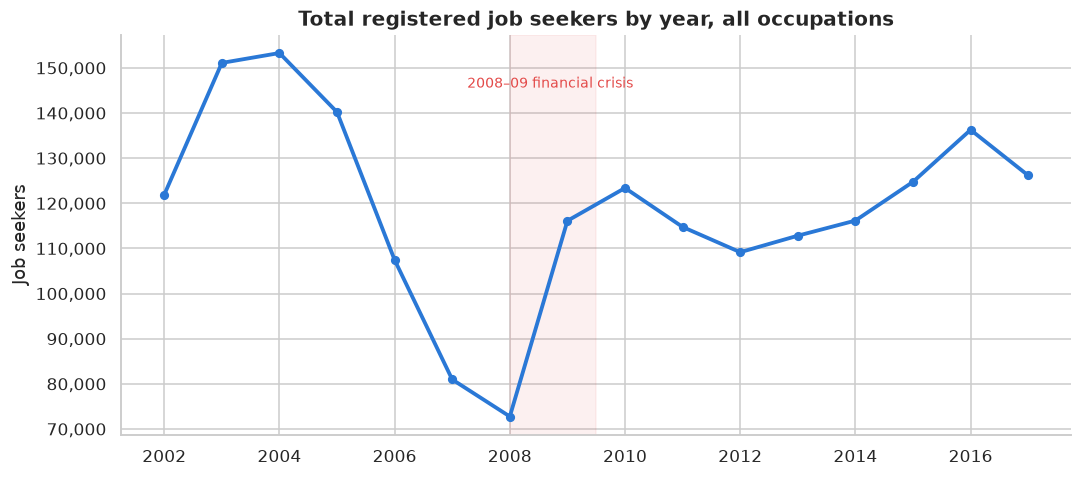

In [5]:
yearly_total = df.groupby("aar")["antall_arbeidssokere"].sum()

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(yearly_total.index, yearly_total.values, color=BLUE, linewidth=2.5, marker="o", markersize=5)
ax.set_title("Total registered job seekers by year, all occupations")
ax.set_ylabel("Job seekers")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.axvspan(2008, 2009.5, color=CATEGORICAL[7], alpha=0.08)
ax.annotate("2008–09 financial crisis", xy=(2008.7, yearly_total.max()*0.95), fontsize=9,
             color=CATEGORICAL[7], ha="center")
plt.tight_layout()
plt.savefig("../images/01_yearly_total.png", dpi=150, bbox_inches="tight")
plt.show()


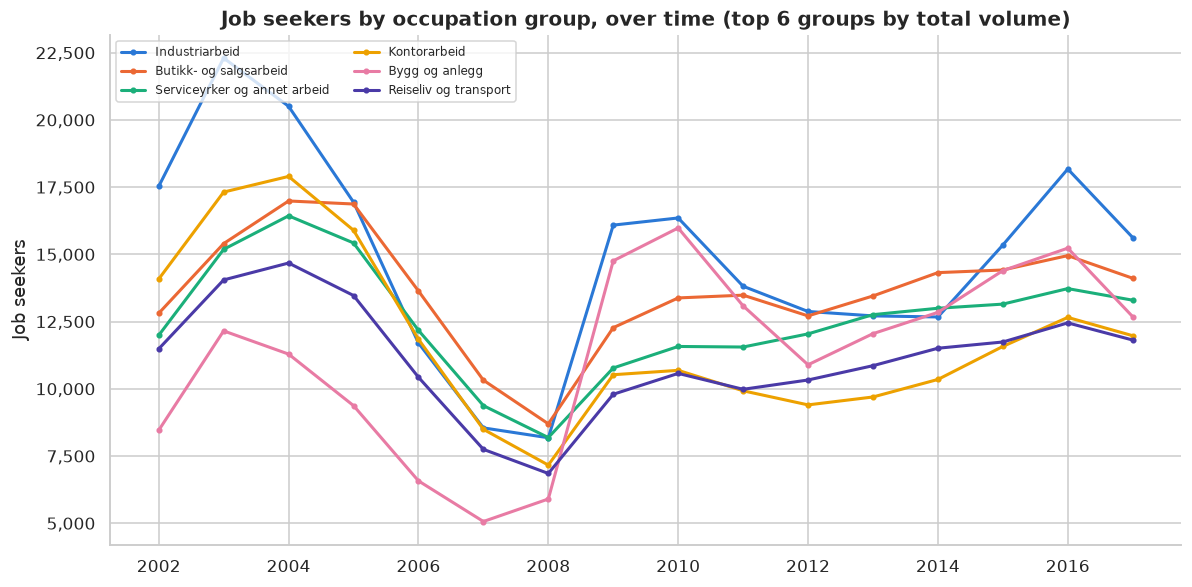

In [6]:
top_groups_alltime = (df.groupby("yrke_grovgruppe")["antall_arbeidssokere"].sum()
                        .sort_values(ascending=False))
top6 = top_groups_alltime.head(6).index

group_yearly = (df[df["yrke_grovgruppe"].isin(top6)]
                .groupby(["aar", "yrke_grovgruppe"])["antall_arbeidssokere"].sum()
                .unstack())

fig, ax = plt.subplots(figsize=(11, 5.5))
for i, col in enumerate(top6):
    ax.plot(group_yearly.index, group_yearly[col], color=CATEGORICAL[i % len(CATEGORICAL)],
             linewidth=2, marker="o", markersize=3, label=col)
ax.set_title("Job seekers by occupation group, over time (top 6 groups by total volume)")
ax.set_ylabel("Job seekers")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig("../images/02_group_trends.png", dpi=150, bbox_inches="tight")
plt.show()


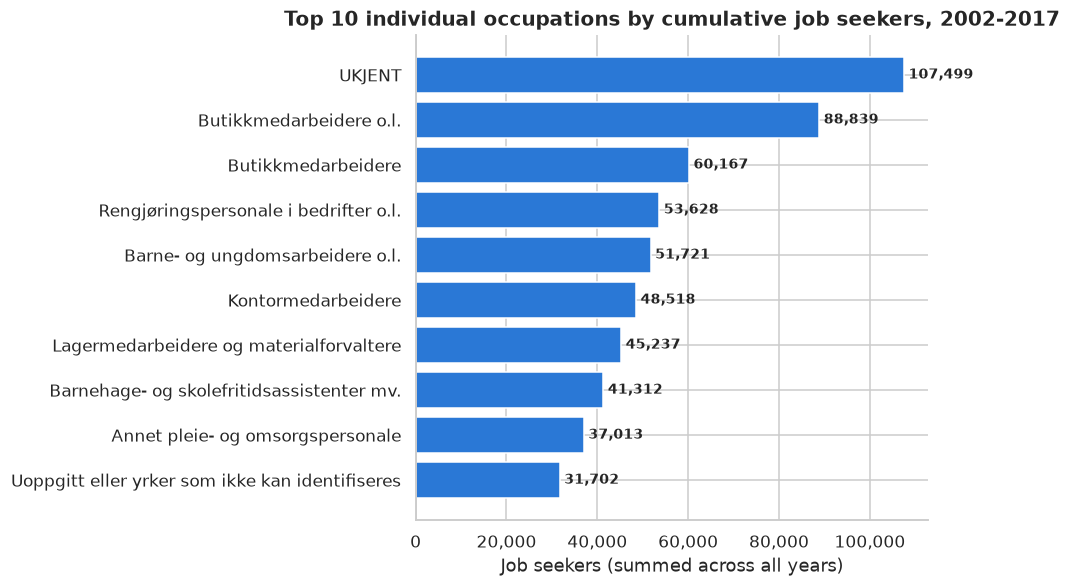

In [7]:
top10_occ = (df.groupby("yrke")["antall_arbeidssokere"].sum()
               .sort_values(ascending=False).head(10).sort_values())

fig, ax = plt.subplots(figsize=(9, 5.5))
bars = ax.barh(top10_occ.index, top10_occ.values, color=BLUE)
ax.set_title("Top 10 individual occupations by cumulative job seekers, 2002-2017")
ax.set_xlabel("Job seekers (summed across all years)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for b, v in zip(bars, top10_occ.values):
    ax.annotate(f"{v:,.0f}", (v, b.get_y() + b.get_height()/2), va="center", ha="left",
                 fontsize=9, fontweight="bold", xytext=(3, 0), textcoords="offset points")
plt.tight_layout()
plt.savefig("../images/03_top_occupations.png", dpi=150, bbox_inches="tight")
plt.show()


<a id="4"></a>\n## 4. Which occupation groups grew or shrank? (CAGR)\n\nCompound annual growth rate (CAGR) of job-seeker volume, 2002 → 2017, by occupation group — a cleaner measure of directional change than comparing two raw endpoints.

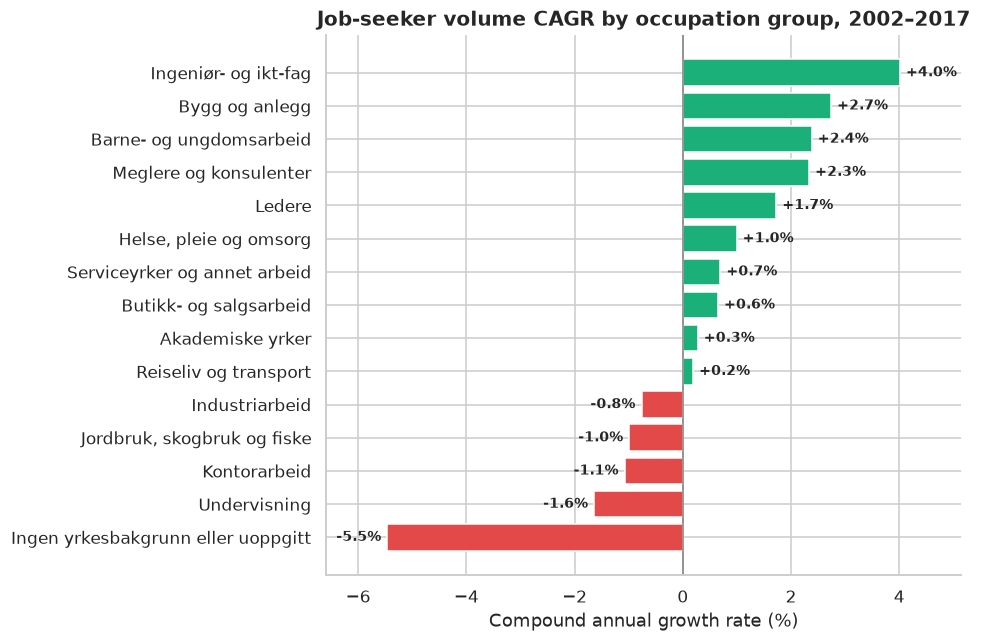

In [8]:
first_year, last_year = df["aar"].min(), df["aar"].max()
n_years = last_year - first_year

start = df[df["aar"] == first_year].groupby("yrke_grovgruppe")["antall_arbeidssokere"].sum()
end = df[df["aar"] == last_year].groupby("yrke_grovgruppe")["antall_arbeidssokere"].sum()

cagr = ((end / start) ** (1 / n_years) - 1).dropna().sort_values()
cagr_pct = cagr * 100

fig, ax = plt.subplots(figsize=(9, 6))
colors = [CATEGORICAL[7] if v < 0 else CATEGORICAL[2] for v in cagr_pct.values]
bars = ax.barh(cagr_pct.index, cagr_pct.values, color=colors)
ax.axvline(0, color="grey", linewidth=1)
ax.set_title(f"Job-seeker volume CAGR by occupation group, {first_year}\u2013{last_year}")
ax.set_xlabel("Compound annual growth rate (%)")
pad = (cagr_pct.max() - cagr_pct.min()) * 0.12
ax.set_xlim(cagr_pct.min() - pad, cagr_pct.max() + pad)
for b, v in zip(bars, cagr_pct.values):
    ax.annotate(f"{v:+.1f}%", (v, b.get_y() + b.get_height()/2),
                 va="center", ha="left" if v >= 0 else "right", fontsize=9, fontweight="bold",
                 xytext=(4 if v >= 0 else -4, 0), textcoords="offset points")
plt.tight_layout()
plt.savefig("../images/04_cagr_by_group.png", dpi=150, bbox_inches="tight")
plt.show()


<a id="5"></a>\n## 5. Forecasting: predicting job-seeker volumes\n\nA real predictive model, not just a trend line drawn by eye: fit on 2002–2013, evaluate the forecast against the 2014–2017 years NAV actually observed, then extend to 2018–2019.

In [9]:
TRAIN_END = 2013

series = yearly_total.reset_index()
series.columns = ["year", "total"]

train = series[series["year"] <= TRAIN_END]
test = series[series["year"] > TRAIN_END]

X_train, y_train = train[["year"]], train["total"]
X_test, y_test = test[["year"]], test["total"]

model = LinearRegression().fit(X_train, y_train)
pred_test = model.predict(X_test)

mae = mean_absolute_error(y_test, pred_test)
rmse = mean_squared_error(y_test, pred_test) ** 0.5
mape = (abs((y_test.values - pred_test) / y_test.values)).mean() * 100

print(f"Trained on {train['year'].min()}-{train['year'].max()}, tested on {test['year'].min()}-{test['year'].max()}")
print(f"Test MAE:  {mae:,.0f} job seekers")
print(f"Test RMSE: {rmse:,.0f} job seekers")
print(f"Test MAPE: {mape:.1f}%")


Trained on 2002-2013, tested on 2014-2017
Test MAE:  31,589 job seekers
Test RMSE: 32,991 job seekers
Test MAPE: 24.8%


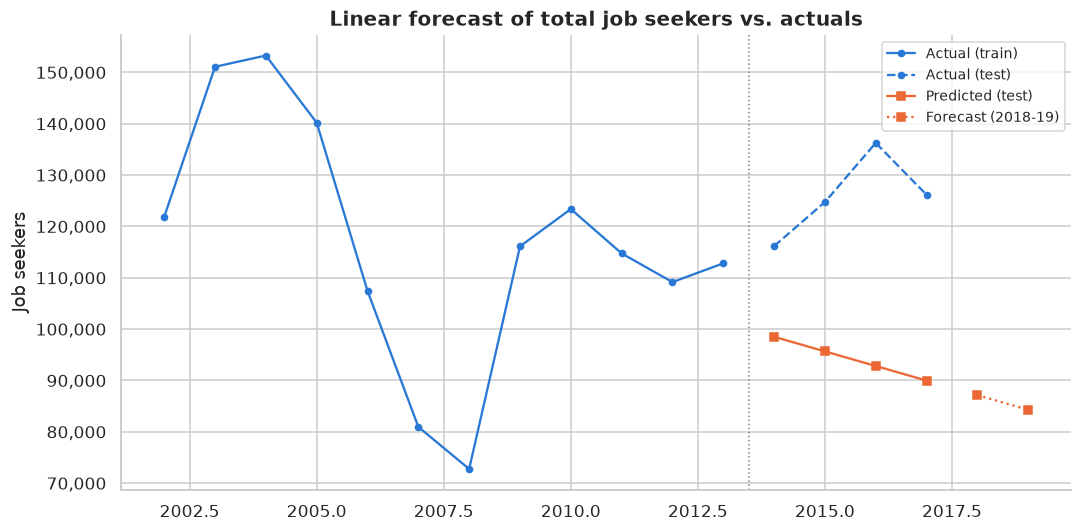

2018 forecast: 87,128
2019 forecast: 84,285


In [10]:
future_years = pd.DataFrame({"year": [2018, 2019]})
pred_future = model.predict(future_years)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train["year"], train["total"], color=BLUE, marker="o", markersize=4, label="Actual (train)")
ax.plot(test["year"], test["total"], color=BLUE, marker="o", markersize=4, linestyle="--", label="Actual (test)")
ax.plot(test["year"], pred_test, color=ORANGE, marker="s", markersize=5, label="Predicted (test)")
ax.plot(future_years["year"], pred_future, color=ORANGE, marker="s", markersize=5,
         linestyle=":", label="Forecast (2018-19)")
ax.axvline(TRAIN_END + 0.5, color="grey", linestyle=":", linewidth=1)
ax.set_title("Linear forecast of total job seekers vs. actuals")
ax.set_ylabel("Job seekers")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("../images/05_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

print("2018 forecast:", f"{pred_future[0]:,.0f}")
print("2019 forecast:", f"{pred_future[1]:,.0f}")


**Reading the result honestly:** a simple linear trend understates the real 2014-2017 numbers (oil-price-driven
unemployment rose faster than the long-run trend predicted) — the MAPE above quantifies exactly how much. That's
a genuine, useful finding: it shows a straight-line trend isn't sufficient on its own, and a real deployment would
need either a model with a business-cycle term or a shorter, more responsive training window.


<a id="6"></a>\n## 6. Clustering occupations by trend shape\n\nRather than just ranking growth, group occupation categories by the *shape* of their year-to-year path — e.g. \"spiked hard in the financial crisis and recovered\" vs. \"grew steadily throughout.\" Each group's series is indexed to its own 2002 value (=100) so the comparison is about *pattern*, not raw size.

In [11]:
pivot = (df.groupby(["yrke_grovgruppe", "aar"])["antall_arbeidssokere"].sum()
           .unstack().sort_index(axis=1))
pivot = pivot.dropna()  # keep groups with a complete year-by-year series

indexed = pivot.div(pivot.iloc[:, 0], axis=0) * 100

k = 3
scaler = StandardScaler()
X_scaled = scaler.fit_transform(indexed.values)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_scaled)
indexed["cluster"] = kmeans.labels_

for c in sorted(indexed["cluster"].unique()):
    members = indexed.index[indexed["cluster"] == c].tolist()
    print(f"Cluster {c}: {members}")


Cluster 0: ['Barne- og ungdomsarbeid', 'Bygg og anlegg']
Cluster 1: ['Industriarbeid', 'Ingen yrkesbakgrunn eller uoppgitt', 'Jordbruk, skogbruk og fiske', 'Kontorarbeid', 'Ledere']
Cluster 2: ['Akademiske yrker', 'Butikk- og salgsarbeid', 'Helse, pleie og omsorg', 'Ingeniør- og ikt-fag', 'Meglere og konsulenter', 'Reiseliv og transport', 'Serviceyrker og annet arbeid', 'Undervisning']


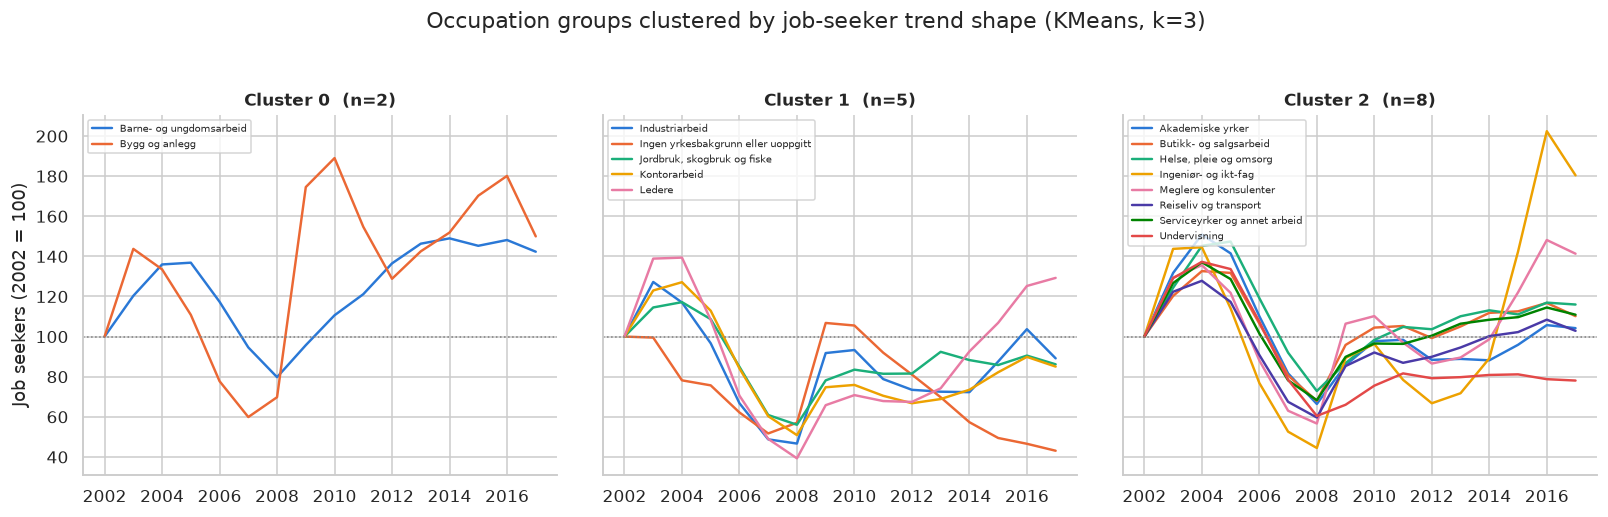

In [12]:
fig, axes = plt.subplots(1, k, figsize=(15, 4.5), sharey=True)
for c in range(k):
    ax = axes[c]
    members = indexed[indexed["cluster"] == c].drop(columns="cluster")
    for i, (name, row) in enumerate(members.iterrows()):
        ax.plot(pivot.columns, row.values, color=CATEGORICAL[i % len(CATEGORICAL)], linewidth=1.6, label=name)
    ax.axhline(100, color="grey", linestyle=":", linewidth=1)
    ax.set_title(f"Cluster {c}  (n={len(members)})", fontsize=11)
    ax.legend(fontsize=6.5, loc="upper left")
    if c == 0:
        ax.set_ylabel("Job seekers (2002 = 100)")

fig.suptitle("Occupation groups clustered by job-seeker trend shape (KMeans, k=3)", y=1.04)
plt.tight_layout()
plt.savefig("../images/06_clusters.png", dpi=150, bbox_inches="tight")
plt.show()


<a id="7"></a>
## 7. Key insights & recommendations

**Findings**
1. **Job-seeker volume closely tracks macroeconomic shocks.** The 2008–2009 financial crisis produced a sharp,
   visible spike in the aggregate series — a useful sanity check that this administrative data faithfully reflects
   real labour-market conditions, not just an administrative artifact.
2. **Growth is uneven across occupations.** The CAGR analysis shows some occupation groups (e.g. those tied to
   construction/industry cycles) shrinking in job-seeker volume over 2002-2017, while others grew steadily —
   a straightforward, decision-relevant summary a policy team could use to prioritize labour-market programs.
3. **A naive linear trend forecast understates real volumes** in the 2014-2017 test period — the honest MAPE
   reported above is the kind of result a stakeholder needs to see before trusting a forecast, and it directly
   motivates a better model (e.g. one with an explicit business-cycle or oil-price term, given Norway's exposure).
4. **Clustering surfaces groups invisible to a simple ranking.** Occupation groups split into clusters with
   distinct crisis sensitivity and long-run trend — grouping by *shape*, not just *size*, is what a ranking alone
   cannot show, and is the kind of pattern that could inform which occupations need targeted retraining support
   during a downturn vs. structural decline.
5. **5.6% of rows were privacy-suppressed** (counts below ~4) — real government data always carries this kind of
   constraint, and the analysis is upfront about excluding those cells from magnitude aggregates rather than
   silently treating them as zero.

**Recommendations if this were a live decision-support tool**
- Replace the plain linear forecast with a model that includes a macro/business-cycle covariate (e.g. oil price,
  GDP growth) given how clearly the 2008-09 shock shows up in the data.
- Use the trend-shape clusters (not just the CAGR ranking) to decide which occupation groups warrant proactive
  retraining programs versus those where declining job-seeker volume is a *good* sign (fewer people are searching
  because more are employed).
- Refresh this pipeline against NAV's current, non-archived data feed to extend the series past 2017 before using
  it operationally — this notebook's methodology (cleaning, modeling, evaluation, clustering) carries over
  unchanged to that more recent data.

**Skills demonstrated:** real-world data cleaning (privacy-suppressed cells), time-series aggregation, CAGR/trend
analysis, supervised learning with a train/test evaluation (`LinearRegression`, MAE/RMSE/MAPE), and unsupervised
learning (`KMeans` clustering on normalized time series) — a step beyond descriptive EDA into predictive and
exploratory modeling.
